# Baseline Analysis


**Goal:** Understand the CIC-IDS2017 data — class imbalances, preprocessing,
SMOTE balancing, XGBoost baseline training, and feature importance.

**Pipeline:** Load ISCX CSVs → Clean → Encode → Split → SMOTE → Train → Evaluate → Save

In [1]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') # Move up one level to the project root

print("Corrected Working Directory:", os.getcwd())

Corrected Working Directory: /home/masko/Spring 2026/cpre560/IDS-ML


In [2]:
import resource

# Limit Python to 20GB — prevents system freeze on large CSVs
resource.setrlimit(resource.RLIMIT_AS, (20 * 1024 * 1024 * 1024, -1))
print('Memory limit: 20GB')

Memory limit: 20GB


In [3]:
# === CELL 0: Imports & Configuration ===
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from pathlib import Path
import pickle, time, gc, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('=' * 70)
print('CICIDS2017 BASELINE ANALYSIS')
print('=' * 70)

# ── Configuration — edit these if needed ──────────────────────────────────
SAMPLE_FRACTION       = 0.10   # 10% of each file — safe for most machines
MIN_SAMPLES_PER_CLASS = 10     # drop classes smaller than this after sampling
RANDOM_STATE          = 42

# ── Paths (match actual repo structure) ───────────────────────────────────
DATA_PATH    = Path('data/dataset')   
RESULTS_PATH = Path('output')         
MODELS_PATH  = Path('models')

print(f'\nData path   : {DATA_PATH.absolute()}')
print(f'Output path : {RESULTS_PATH.absolute()}')
print(f'Models path : {MODELS_PATH.absolute()}')

# Validate expected repo folders exist
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Data folder not found: {DATA_PATH.absolute()}\nMake sure ISCX files are in data/dataset/')
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f'Output folder not found: {RESULTS_PATH.absolute()}\nMake sure you are running from the project root.')
if not MODELS_PATH.exists():
    raise FileNotFoundError(f'Models folder not found: {MODELS_PATH.absolute()}\nMake sure you are running from the project root.')
print('All repo folders found OK')

CICIDS2017 BASELINE ANALYSIS

Data path   : /home/masko/Spring 2026/cpre560/IDS-ML/data/dataset
Output path : /home/masko/Spring 2026/cpre560/IDS-ML/output
Models path : /home/masko/Spring 2026/cpre560/IDS-ML/models
All repo folders found OK


In [4]:
# === CELL 1: Load ISCX CSVs ===
print('\n' + '=' * 70)
print('LOADING CICIDS2017 DATA')
print('=' * 70)

csv_files = sorted(DATA_PATH.glob('*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {f.name}  ({f.stat().st_size / 1024**2:.1f} MB)')

if not csv_files:
    raise FileNotFoundError(
        f'No CSVs found in {DATA_PATH.absolute()}\n'
        f'Make sure the ISCX files are in data/dataset/')

# Load all files — use latin-1 fallback for Windows-encoded ISCX files
print(f'\nLoading {len(csv_files)} files at {SAMPLE_FRACTION*100:.0f}% sample rate...')
start_time = time.time()
dfs = []
total_records = 0

for filepath in csv_files:
    print(f'  {filepath.name[:55]:55s}...', end=' ', flush=True)
    try:
        df = pd.read_csv(filepath, low_memory=False, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, low_memory=False, encoding='latin-1')
    df.columns = df.columns.str.strip()
    dfs.append(df)
    total_records += len(df)
    print(f'({len(df):,} rows)')
    gc.collect()

df_combined = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f'\nLoaded in {time.time() - start_time:.1f}s')
print(f'  Combined shape : {df_combined.shape}')
print(f'  Total records  : {total_records:,}')


LOADING CICIDS2017 DATA
Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)

Loading 8 files at 10% sample rate...
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv       ... (225,745 rows)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv   ... (286,467 rows)
  Friday-WorkingHours-Morning.pcap_ISCX.csv              ... (191,033 rows)
  Monday-WorkingHours.pcap_ISCX.csv                      ... (529,918 rows)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX... (288,602 rows)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ... (170

In [5]:
# === CELL 2: Clean & Preprocess ===
print('\n' + '=' * 70)
print('DATA CLEANING & PREPROCESSING')
print('=' * 70)

# Detect and normalise the label column name
# ISCX files sometimes have ' Label' with a leading space
raw_label = df_combined.columns[-1]
df_combined.rename(columns={raw_label: 'Label'}, inplace=True)
label_col = 'Label'
print(f'Label column   : "{raw_label}" → normalised to "{label_col}"')
print(f'Classes found  : {df_combined[label_col].nunique()}')

# Replace inf/-inf, then drop NaN
df_combined.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned = df_combined.dropna().copy()
print(f'After dropna   : {len(df_cleaned):,} rows')
del df_combined
gc.collect()

# Normalise label strings (ISCX uses mixed case and special chars)
label_map = {
    'Web Attack \x96 Brute Force':   'Web Attack Brute Force',
    'Web Attack \x96 Sql Injection': 'Web Attack Sql Injection',
    'Web Attack \x96 XSS':          'Web Attack XSS',
}
df_cleaned[label_col] = df_cleaned[label_col].str.strip().replace(label_map)

# Per-class sample (keeps class proportions, limits memory)
# Note: pandas 3.0 drops the groupby key from output when using .apply()
# so we use a concat loop instead — works on all pandas versions
print(f'\nSampling {SAMPLE_FRACTION*100:.0f}% per class...')
df_cleaned = pd.concat([
    grp.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE)
    for _, grp in df_cleaned.groupby(label_col, group_keys=False)
]).reset_index(drop=True)
print(f'After sampling : {len(df_cleaned):,} rows')

# Drop classes with too few samples to be useful
counts = df_cleaned[label_col].value_counts()
keep   = counts[counts >= MIN_SAMPLES_PER_CLASS].index
removed = counts[counts < MIN_SAMPLES_PER_CLASS].index.tolist()
if removed:
    print(f'\nDropping rare classes (< {MIN_SAMPLES_PER_CLASS} samples): {removed}')
    df_cleaned = df_cleaned[df_cleaned[label_col].isin(keep)]

gc.collect()
print(f'\nFinal shape    : {df_cleaned.shape}')


DATA CLEANING & PREPROCESSING
Label column   : "Label" → normalised to "Label"
Classes found  : 15
After dropna   : 2,827,876 rows

Sampling 10% per class...
After sampling : 282,788 rows

Dropping rare classes (< 10 samples): ['Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']

Final shape    : (282781, 79)



CLASS DISTRIBUTION

Attack Type                            Count  % Dataset  vs Majority
----------------------------------------------------------------------
BENIGN                               227,132     80.32%    100.0000%
DoS Hulk                              23,012      8.14%     10.1316%
PortScan                              15,880      5.62%      6.9915%
DDoS                                  12,802      4.53%      5.6364%
DoS GoldenEye                          1,029      0.36%      0.4530%
FTP-Patator                              794      0.28%      0.3496%
SSH-Patator                              590      0.21%      0.2598%
DoS slowloris                            580      0.21%      0.2554%
DoS Slowhttptest                         550      0.19%      0.2421%
Bot                                      196      0.07%      0.0863%
Web Attack � Brute Force                 151      0.05%      0.0665%
Web Attack � XSS                          65      0.02%      0.0286%

Saved clas

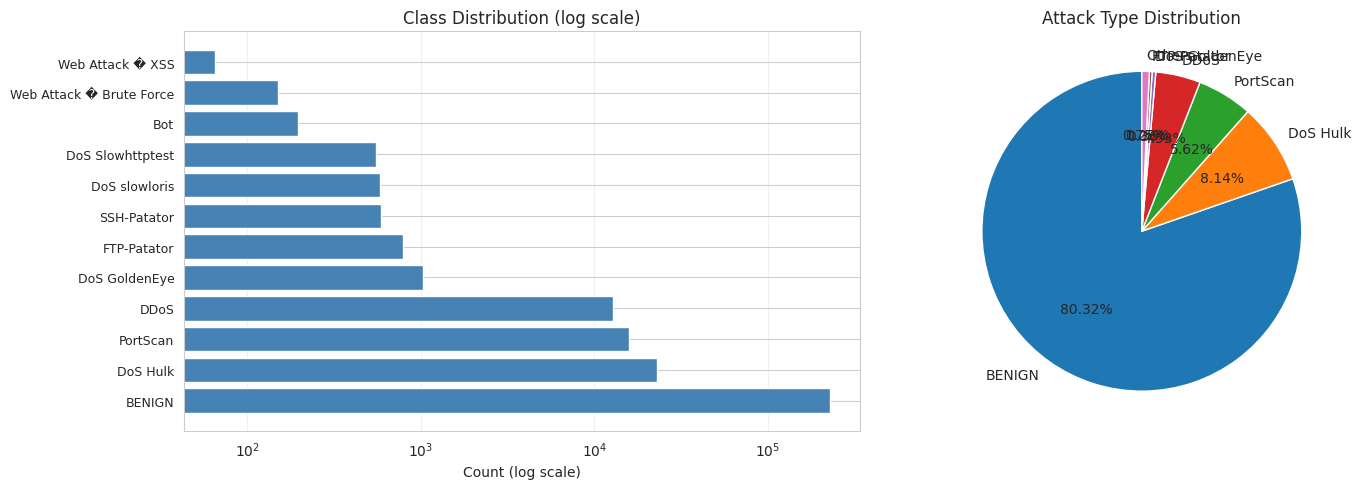

Saved class_imbalance.png


In [6]:
# === CELL 3: Class Distribution Analysis ===
print('\n' + '=' * 70)
print('CLASS DISTRIBUTION')
print('=' * 70)

class_counts = df_cleaned[label_col].value_counts()
class_pct    = (class_counts / len(df_cleaned) * 100).round(4)

print(f'\n{"Attack Type":<35} {"Count":>8} {"% Dataset":>10} {"vs Majority":>12}')
print('-' * 70)
for cls, count in class_counts.items():
    vs = count / class_counts.iloc[0] * 100
    print(f'{cls:<35} {count:>8,} {class_pct[cls]:>9.2f}% {vs:>11.4f}%')

pd.DataFrame({'Count': class_counts, '% Dataset': class_pct}).to_csv(
    RESULTS_PATH / 'class_distribution.csv')
print(f'\nSaved class_distribution.csv')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(range(len(class_counts)), class_counts.values, color='steelblue')
axes[0].set_yticks(range(len(class_counts)))
axes[0].set_yticklabels(class_counts.index, fontsize=9)
axes[0].set_xlabel('Count (log scale)')
axes[0].set_xscale('log')
axes[0].set_title('Class Distribution (log scale)')
axes[0].grid(axis='x', alpha=0.3)

top_n   = min(6, len(class_pct))
top_cls = class_pct.nlargest(top_n)
other   = class_pct.iloc[top_n:].sum()
pie_d   = list(top_cls.values) + ([other] if other > 0 else [])
pie_l   = list(top_cls.index)  + (['Others'] if other > 0 else [])
axes[1].pie(pie_d, labels=pie_l, autopct='%1.2f%%', startangle=90)
axes[1].set_title('Attack Type Distribution')

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved class_imbalance.png')

In [7]:
# === CELL 4: Feature Encoding ===
print('\n' + '=' * 70)
print('FEATURE PREPARATION & ENCODING')
print('=' * 70)

feature_cols    = [c for c in df_cleaned.columns if c != label_col]
X               = df_cleaned[feature_cols].copy()
y               = df_cleaned[label_col].copy()

# Encode any categorical (non-numeric) feature columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical cols : {categorical_cols if categorical_cols else "none"}')
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f'Classes ({len(le_target.classes_)}) : {list(le_target.classes_)}')

# Final inf/NaN sweep
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))
print(f'\nFeature matrix : {X.shape}')
gc.collect()


FEATURE PREPARATION & ENCODING
Categorical cols : none
Classes (12) : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � XSS']

Feature matrix : (282781, 78)


2854

In [8]:
# === CELL 5: Train / Test Split ===
print('\n' + '=' * 70)
print('TRAIN-TEST SPLIT')
print('=' * 70)

min_cls = np.bincount(y_encoded).min()
print(f'Min samples in any class: {min_cls}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded if min_cls >= 2 else None
)

print(f'Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}')
train_counts = np.bincount(y_train)
for i, name in enumerate(le_target.classes_):
    if i < len(train_counts):
        pct = train_counts[i] / len(y_train) * 100
        print(f'  {name:<35} {train_counts[i]:>7,}  ({pct:.2f}%)')
gc.collect()


TRAIN-TEST SPLIT
Min samples in any class: 65
Train : 226,224  |  Test : 56,557
  BENIGN                              181,705  (80.32%)
  Bot                                     157  (0.07%)
  DDoS                                 10,242  (4.53%)
  DoS GoldenEye                           823  (0.36%)
  DoS Hulk                             18,409  (8.14%)
  DoS Slowhttptest                        440  (0.19%)
  DoS slowloris                           464  (0.21%)
  FTP-Patator                             635  (0.28%)
  PortScan                             12,704  (5.62%)
  SSH-Patator                             472  (0.21%)
  Web Attack � Brute Force                121  (0.05%)
  Web Attack � XSS                         52  (0.02%)


0

In [9]:
# === CELL 6: SMOTE Balancing ===
# Must run BEFORE training — XGBoost cell uses X_train_balanced / y_train_balanced
print('\n' + '=' * 70)
print('SMOTE BALANCING')
print('=' * 70)

train_counts   = np.bincount(y_train)
majority_count = train_counts.max()
target_count   = max(int(majority_count * 0.05), 500)
MIN_SMOTE      = 50

sampling_strategy = {}
small_classes     = []

for i, name in enumerate(le_target.classes_):
    if i >= len(train_counts): continue
    count = train_counts[i]
    if count < MIN_SMOTE:
        small_classes.append(i)
        print(f'  {name}: {count:,} (too few for SMOTE — class weighting only)')
    elif count < target_count:
        sampling_strategy[i] = target_count
        print(f'  {name}: {count:,} → {target_count:,}')
    else:
        print(f'  {name}: {count:,} (no change)')

if sampling_strategy:
    k = min(5, min(train_counts[i] for i in sampling_strategy) - 1)
    print(f'\n  k_neighbors = {k}')
    smote = SMOTE(sampling_strategy=sampling_strategy,
                  random_state=RANDOM_STATE, k_neighbors=k)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f'  {len(X_train):,} → {len(X_train_balanced):,} training samples after SMOTE')
else:
    print('  No SMOTE needed')
    X_train_balanced = X_train
    y_train_balanced = y_train

# Sample weights for class-weighted training (handles classes too small for SMOTE)
bal_counts     = np.bincount(y_train_balanced)
total_bal      = bal_counts.sum()
n_cls          = len(bal_counts)
sample_weights = np.array([total_bal / (n_cls * bal_counts[y]) for y in y_train_balanced])
print(f'  Sample weights computed')
gc.collect()


SMOTE BALANCING
  BENIGN: 181,705 (no change)
  Bot: 157 → 9,085
  DDoS: 10,242 (no change)
  DoS GoldenEye: 823 → 9,085
  DoS Hulk: 18,409 (no change)
  DoS Slowhttptest: 440 → 9,085
  DoS slowloris: 464 → 9,085
  FTP-Patator: 635 → 9,085
  PortScan: 12,704 (no change)
  SSH-Patator: 472 → 9,085
  Web Attack � Brute Force: 121 → 9,085
  Web Attack � XSS: 52 → 9,085

  k_neighbors = 5
  226,224 → 295,740 training samples after SMOTE
  Sample weights computed


0

In [ ]:
# === CELL 7: Train XGBoost ===
print('\n' + '=' * 70)
print('TRAINING XGBOOST CLASSIFIER')
print('=' * 70)

print(f'XGBoost version  : {xgb.__version__}')
print(f'Training samples : {X_train_balanced.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Classes          : {len(le_target.classes_)}')

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0,
)

print('\nTraining...')
start = time.time()
model.fit(X_train_balanced, y_train_balanced,
          sample_weight=sample_weights, verbose=False)
train_time = time.time() - start
print(f'Done in {train_time:.1f}s')
gc.collect()


TRAINING XGBOOST CLASSIFIER
XGBoost version  : 3.2.0
Training samples : 295,740
Test samples     : 56,557
Classes          : 12

Training...


In [ ]:
# === CELL 8: Feature Importance ===
print('\n' + '=' * 70)
print('FEATURE IMPORTANCE')
print('=' * 70)

feat_imp = pd.DataFrame({
    'Feature':    list(X_train.columns),  # explicit list — safe after SMOTE
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feat_imp['Cumulative %'] = (
    feat_imp['Importance'].cumsum() / feat_imp['Importance'].sum() * 100
).round(2)

print('\nTop 20:')
print('-' * 60)
for _, row in feat_imp.head(20).iterrows():
    print(f'  {row["Feature"]:<40} {row["Importance"]:.6f}')

features_80 = (feat_imp['Cumulative %'] <= 80).sum()
features_95 = (feat_imp['Cumulative %'] <= 95).sum()
print(f'\nFeatures for 80% importance : {features_80}')
print(f'Features for 95% importance : {features_95}')

feat_imp.to_csv(RESULTS_PATH / 'feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 8))
top = feat_imp.head(20)
ax.barh(range(len(top)), top['Importance'].values, color='steelblue')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['Feature'].values, fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Features — Gain Importance (XGBoost)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved feature_importance.png')

In [ ]:
# === CELL 9: Evaluate ===
print('\n' + '=' * 70)
print('MODEL EVALUATION')
print('=' * 70)

start    = time.time()
y_pred   = model.predict(X_test)
pred_time = time.time() - start
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy         : {accuracy*100:.2f}%')
print(f'Inference speed  : {len(X_test)/pred_time:,.0f} samples/s')
print()
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Save report
pd.DataFrame(
    classification_report(y_test, y_pred, target_names=le_target.classes_, output_dict=True)
).T.to_csv(RESULTS_PATH / 'classification_report.csv')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax)
ax.set_title('Confusion Matrix — Baseline XGBoost')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')
gc.collect()

In [ ]:
# === CELL 10: Save Model & Artifacts ===
print('\n' + '=' * 70)
print('SAVING MODEL & ARTIFACTS')
print('=' * 70)

model.save_model(str(MODELS_PATH / 'baseline_xgboost.json'))
print('Saved baseline_xgboost.json')

preprocessing_info = {
    'categorical_encoders': label_encoders,
    'target_encoder':       le_target,
    'feature_columns':      feature_cols,
    'categorical_columns':  categorical_cols,
}
with open(MODELS_PATH / 'preprocessing_info.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)
print('Saved preprocessing_info.pkl')

# Summary
summary = {
    'Total records loaded': f'{total_records:,}',
    'Sample fraction':      f'{SAMPLE_FRACTION*100:.0f}%',
    'Final dataset size':   f'{len(df_cleaned):,}',
    'Classes':              len(le_target.classes_),
    'Features':             len(feature_cols),
    'Train samples':        f'{X_train_balanced.shape[0]:,}',
    'Test samples':         f'{len(X_test):,}',
    'Train time (s)':       f'{train_time:.2f}',
    'Accuracy':             f'{accuracy*100:.2f}%',
    'Features → 80% imp':   features_80,
    'Features → 95% imp':   features_95,
    'Top feature':          feat_imp.iloc[0]['Feature'],
}

print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
for k, v in summary.items():
    print(f'  {k:<35} {v}')

pd.DataFrame(list(summary.items()), columns=['Metric','Value']).to_csv(
    RESULTS_PATH / 'metrics_summary.csv', index=False)
print('\nSaved metrics_summary.csv')
print('\nBaseline analysis complete!')